# Model Evaluation & Comparison

Reads pre-computed metrics from every model notebook and produces a single cross-model,
cross-frequency leaderboard. Run after all model notebooks have been executed.

**Models covered**

| Model | Weekly | Daily |
|---|:---:|:---:|
| ARIMA / ARIMAX | ✓ | ✓ |
| VAR | ✓ | ✓ |
| Random Forest | ✓ | ✓ |
| XGBoost | ✓ | ✓ |
| LSTM | ✓ | — |
| MIDAS | ✓ | — |

**Primary metric**: WDA (Weighted Directional Accuracy) — weights correct direction calls
by the magnitude of the actual return. Secondary: DA, RMSE, MAE.

In [182]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA = '../data/processed/'

## 1. Load & harmonise metrics

In [183]:
# file → (frequency, model family)
metrics_map = {
    'metrics_arima.csv':         ('Weekly', 'ARIMA'),
    'metrics_var.csv':           ('Weekly', 'VAR'),
    'metrics_rf.csv':            ('Weekly', 'Random Forest'),
    'metrics_xgboost.csv':       ('Weekly', 'XGBoost'),
    'metrics_lstm_weekly.csv':   ('Weekly', 'LSTM'),
    'metrics_midas.csv':         ('Weekly', 'MIDAS'),
    'metrics_arima_daily.csv':   ('Daily',  'ARIMA'),
    'metrics_var_daily.csv':     ('Daily',  'VAR'),
    'metrics_rf_daily.csv':      ('Daily',  'Random Forest'),
    'metrics_lstm_daily.csv':    ('Daily',  'LSTM'),
    'metrics_xgboost_daily.csv': ('Daily',  'XGBoost'),
}

frames = []
for fname, (freq, family) in metrics_map.items():
    path = DATA + fname
    if not os.path.exists(path):
        print(f'Missing: {fname}')
        continue
    df = pd.read_csv(path)
    df = df.rename(columns={'dir_acc': 'da'})
    df['frequency'] = freq
    df['family']    = family
    frames.append(df)

all_metrics = pd.concat(frames, ignore_index=True)

# Convert log-return errors to percentage points for interpretability
# RMSE=0.013 log-return → 1.3% per day; RMSE=0.052 → 5.2% per week
all_metrics['rmse'] *= 100
all_metrics['mae']  *= 100

# Flag naive / baseline rows
all_metrics['is_naive'] = all_metrics['model'].str.lower().str.startswith('naive')

print(f'Loaded {len(all_metrics)} rows across {all_metrics["family"].nunique()} model families')
all_metrics.head(10)

Missing: metrics_lstm_daily.csv
Loaded 47 rows across 6 model families


,model,rmse,mae,da,wda,frequency,family,is_naive
0,Naive (t-1 week),7.584000,5.386492,0.494253,0.491093,Weekly,ARIMA,True
1,ARIMA expanding,5.180003,3.712474,0.554286,0.584791,Weekly,ARIMA,False
2,ARIMA rolling (100w),5.176458,3.706953,0.520000,0.538525,Weekly,ARIMA,False
3,ARIMAX expanding,5.211687,3.689078,0.537143,0.526216,Weekly,ARIMA,False
4,ARIMAX rolling (100w),5.236241,3.673614,0.565714,0.523705,Weekly,ARIMA,False
5,Naive (t-1 week),7.584000,5.386492,0.494253,0.491093,Weekly,VAR,True
6,VAR(1) expanding,5.220189,3.757610,0.502857,0.497707,Weekly,VAR,False
7,VAR(1) rolling (100w),5.341293,3.897958,0.417143,0.438890,Weekly,VAR,False
8,Naive (t-1 week),7.584000,5.386492,0.494253,0.491093,Weekly,Random Forest,True
9,RF expanding,5.348670,3.753790,0.520000,0.494585,Weekly,Random Forest,False


## 1b. Always-up naive baseline

A strategy that predicts a positive return every period. In a market with positive drift
(silver 2023–2024 test window), this can beat 50% without any model.

- **DA** = fraction of periods where actual return was positive
- **WDA** = fraction of total |return| accounted for by positive-return periods

This is a tighter benchmark than coin-flip (0.50) — any model below this line is
worse than just always predicting "up".

In [184]:
def _always_up(actual):
    pos = actual > 0
    da  = float(pos.mean())
    wda = float(np.abs(actual[pos]).sum() / np.abs(actual).sum()) if np.abs(actual).sum() > 0 else 0.5
    return da, wda

always_up_rows = []

# Weekly actuals — use ARIMA rolling predictions file (reliable, covers full test window)
w_path = DATA + 'preds_arima_rol.csv'
if os.path.exists(w_path):
    actual_w = pd.read_csv(w_path, index_col=0, parse_dates=True)['actual'].dropna().values
    da_w, wda_w = _always_up(actual_w)
    always_up_rows.append({'model': 'Always-up (drift)', 'da': da_w, 'wda': wda_w,
                            'rmse': np.nan, 'mae': np.nan,
                            'frequency': 'Weekly', 'family': 'Baseline', 'is_naive': True})
    print(f'Weekly  n={len(actual_w)}  DA={da_w:.3f}  WDA={wda_w:.3f}')

# Daily actuals — use test.csv directly
d_path = DATA + 'test.csv'
if os.path.exists(d_path):
    actual_d = pd.read_csv(d_path, index_col=0, parse_dates=True)['silver_return'].dropna().values
    da_d, wda_d = _always_up(actual_d)
    always_up_rows.append({'model': 'Always-up (drift)', 'da': da_d, 'wda': wda_d,
                            'rmse': np.nan, 'mae': np.nan,
                            'frequency': 'Daily', 'family': 'Baseline', 'is_naive': True})
    print(f'Daily   n={len(actual_d)}  DA={da_d:.3f}  WDA={wda_d:.3f}')

if always_up_rows:
    all_metrics = pd.concat([all_metrics, pd.DataFrame(always_up_rows)], ignore_index=True)
    print(f'\nAppended {len(always_up_rows)} always-up row(s) to all_metrics')

Weekly  n=175  DA=0.554  WDA=0.585
Daily   n=837  DA=0.538  WDA=0.539

Appended 2 always-up row(s) to all_metrics


## 2. Full leaderboard

Best variant per model family (highest WDA), ranked within each frequency.

In [185]:
models_only = all_metrics[~all_metrics['is_naive']].copy()

# Best variant per family × frequency
best = (
    models_only
    .sort_values('wda', ascending=False)
    .groupby(['frequency', 'family'], sort=False)
    .first()
    .reset_index()
    .sort_values(['frequency', 'wda'], ascending=[True, False])
)

for freq in ['Weekly', 'Daily']:
    sub = best[best['frequency'] == freq][['family', 'model', 'rmse', 'mae', 'da', 'wda']].copy()
    sub = sub.rename(columns={'family': 'Model', 'model': 'Best variant',
                               'rmse': 'RMSE (%)', 'mae': 'MAE (%)'})
    sub[['RMSE (%)', 'MAE (%)']] = sub[['RMSE (%)', 'MAE (%)']].round(2)
    sub[['da', 'wda']]           = sub[['da', 'wda']].round(3)
    print(f'\n── {freq} ──')
    print(sub.to_string(index=False))


── Weekly ──
        Model      Best variant  RMSE (%)  MAE (%)    da   wda
         LSTM         LSTM-EXOG      5.28     3.80 0.576 0.631
        MIDAS        EXOG+Macro      5.37     4.00 0.549 0.585
        ARIMA   ARIMA expanding      5.18     3.71 0.554 0.585
      XGBoost XGBoost expanding      5.18     3.74 0.531 0.582
          VAR  VAR(1) expanding      5.22     3.76 0.503 0.498
Random Forest      RF expanding      5.35     3.75 0.520 0.495

── Daily ──
        Model              Best variant  RMSE (%)  MAE (%)    da   wda
        ARIMA ARIMAX rolling   (lagged)      1.30     1.00 0.696 0.842
          VAR          VAR(1) expanding      2.65     1.63 0.480 0.544
      XGBoost         XGBoost expanding      2.65     1.62 0.502 0.538
Random Forest         RF rolling (500d)      2.68     1.65 0.500 0.530


## 3. Visual comparison — WDA & DA by model

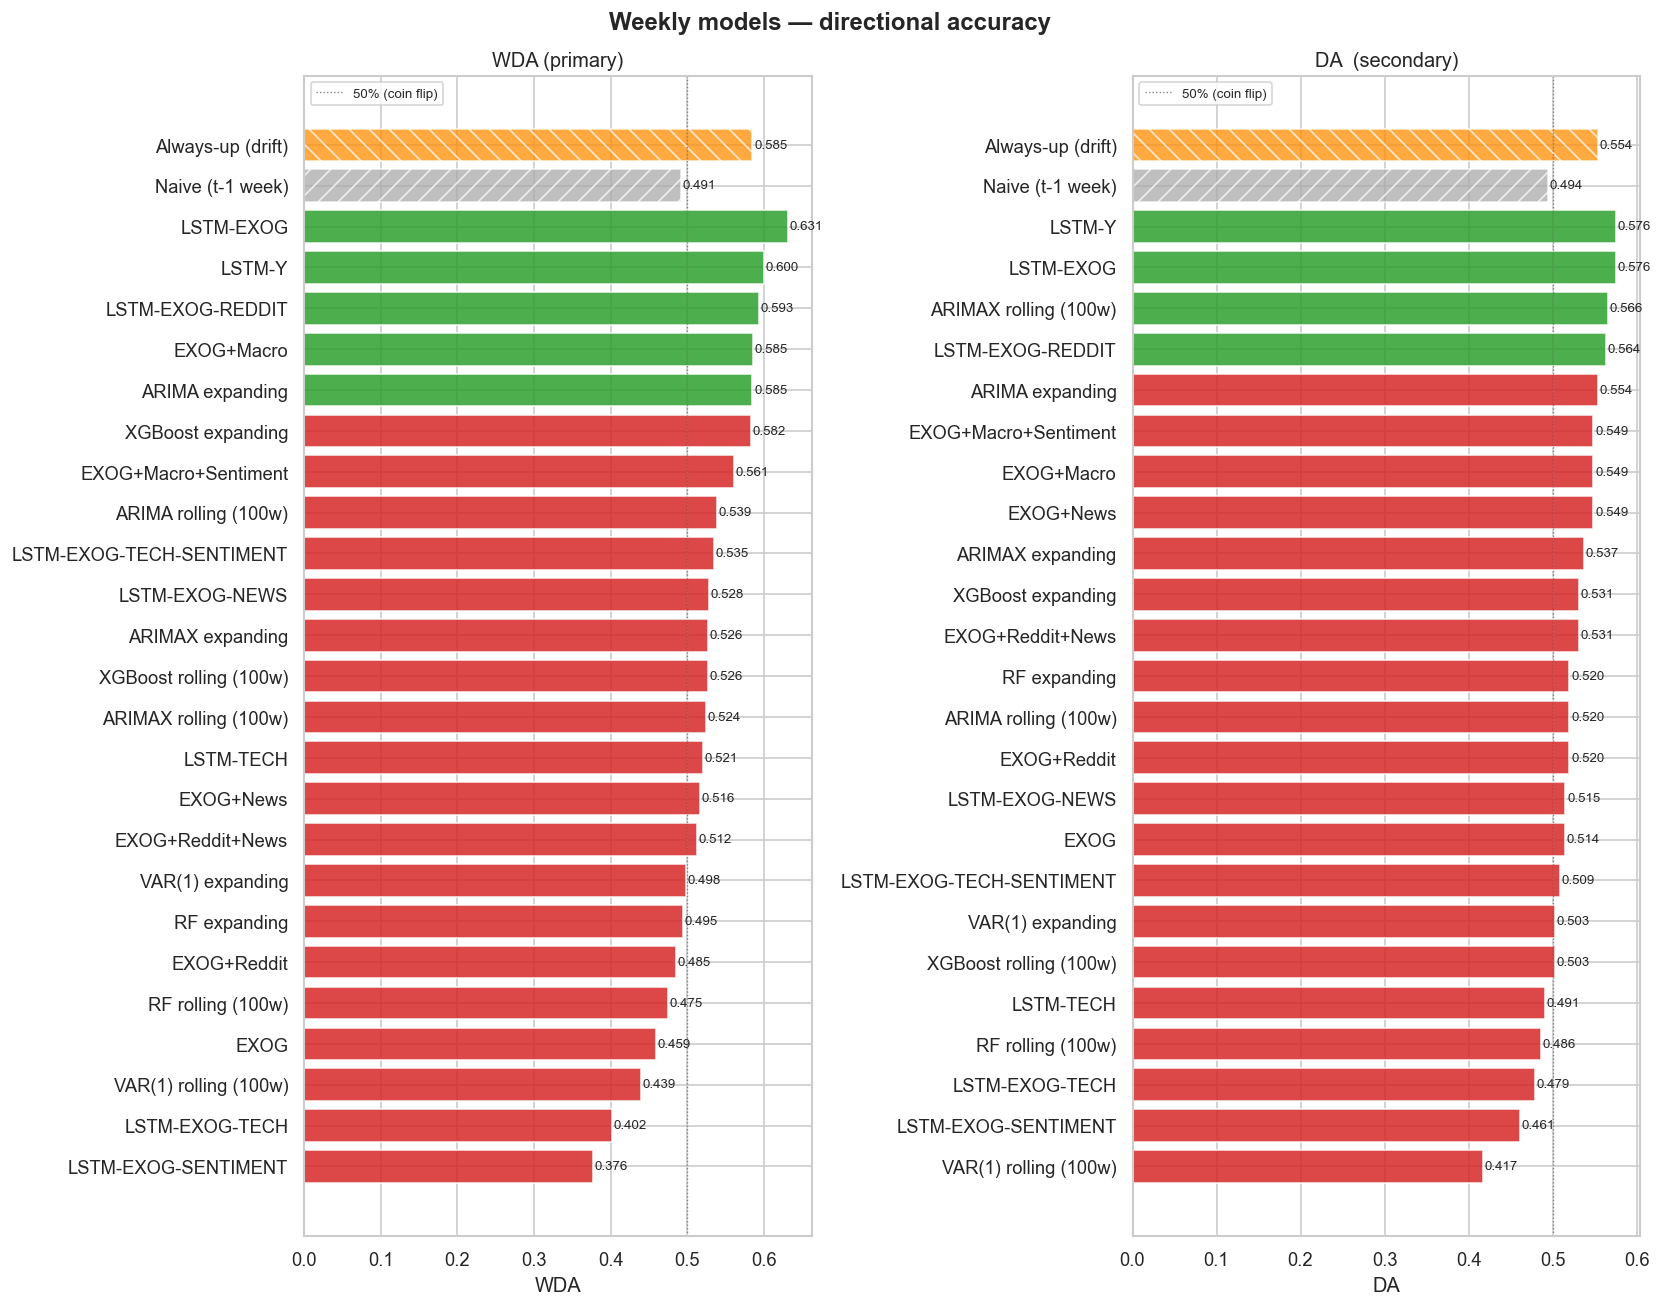

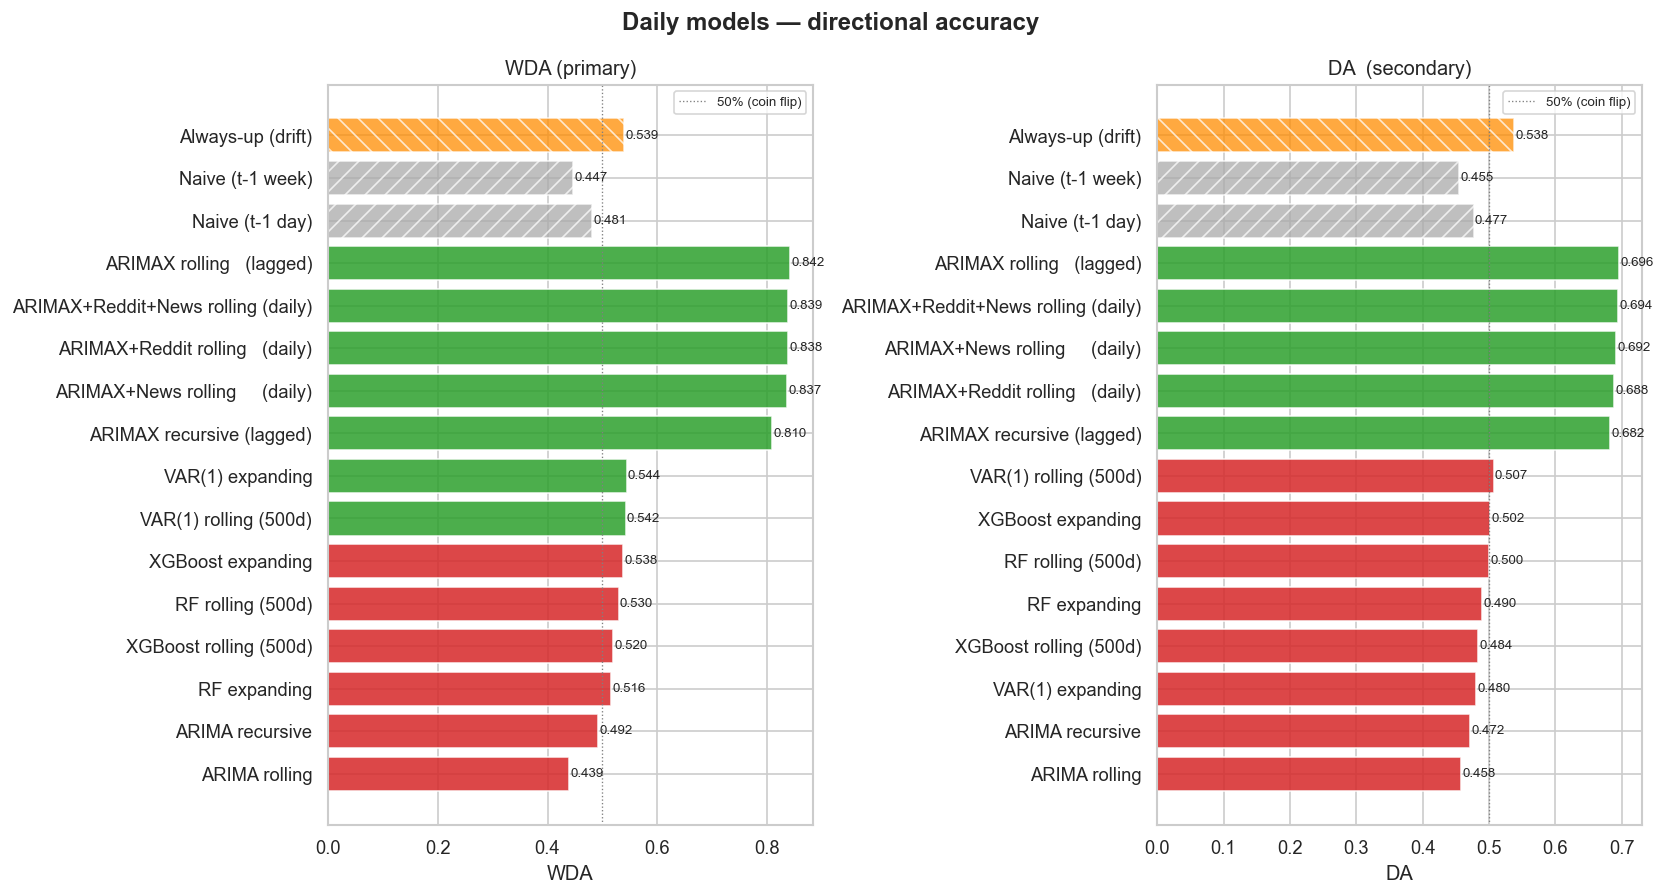

In [186]:
def plot_metric_bars(ax, df_models, df_baselines, metric, title):
    """Bar chart with model bars + baseline bars in grey/orange at the bottom."""
    df = df_models.sort_values(metric, ascending=True)

    # Pick colour threshold: beat the always-up baseline if present, else 0.5
    au = df_baselines[df_baselines['model'] == 'Always-up (drift)'][metric]
    threshold = float(au.iloc[0]) if len(au) else 0.5
    colors = ['#2ca02c' if v > threshold else '#d62728' for v in df[metric]]

    # Model bars
    ax.barh(df['model'], df[metric], color=colors, alpha=0.85)

    # Baseline bars (grey = naive, orange = always-up) — drawn below models
    for _, row in df_baselines.iterrows():
        if row['model'].lower().startswith('naive'):
            ax.barh(row['model'], row[metric], color='#aaaaaa', alpha=0.75,
                    hatch='//', label='_nolegend_')
        elif row['model'] == 'Always-up (drift)':
            ax.barh(row['model'], row[metric], color='darkorange', alpha=0.75,
                    hatch='\\\\', label='_nolegend_')

    ax.axvline(0.5, color='grey', lw=0.8, ls=':', label='50% (coin flip)')
    ax.set_xlabel(metric.upper())
    ax.set_title(title)
    ax.legend(fontsize=8)
    for v, name in zip(df[metric], df['model']):
        ax.text(v + 0.002, name, f'{v:.3f}', va='center', fontsize=8)
    for _, row in df_baselines.iterrows():
        ax.text(row[metric] + 0.002, row['model'], f'{row[metric]:.3f}', va='center', fontsize=8)

for freq in ['Weekly', 'Daily']:
    sub = models_only[models_only['frequency'] == freq]

    # One naive row per frequency (values are identical across model families — just take first)
    naive_rows = (
        all_metrics[
            (all_metrics['frequency'] == freq) &
            all_metrics['model'].str.lower().str.startswith('naive')
        ]
        .drop_duplicates(subset='model')
        [['model', 'wda', 'da']]
    )
    au_rows = all_metrics[
        (all_metrics['frequency'] == freq) &
        (all_metrics['model'] == 'Always-up (drift)')
    ][['model', 'wda', 'da']]

    baselines = pd.concat([naive_rows, au_rows], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, (len(sub) + len(baselines)) * 0.35 + 2)))
    fig.suptitle(f'{freq} models — directional accuracy', fontweight='bold')

    plot_metric_bars(axes[0], sub, baselines, 'wda', 'WDA (primary)')
    plot_metric_bars(axes[1], sub, baselines, 'da',  'DA  (secondary)')

    plt.tight_layout()
    plt.show()

## 4. RMSE / MAE comparison

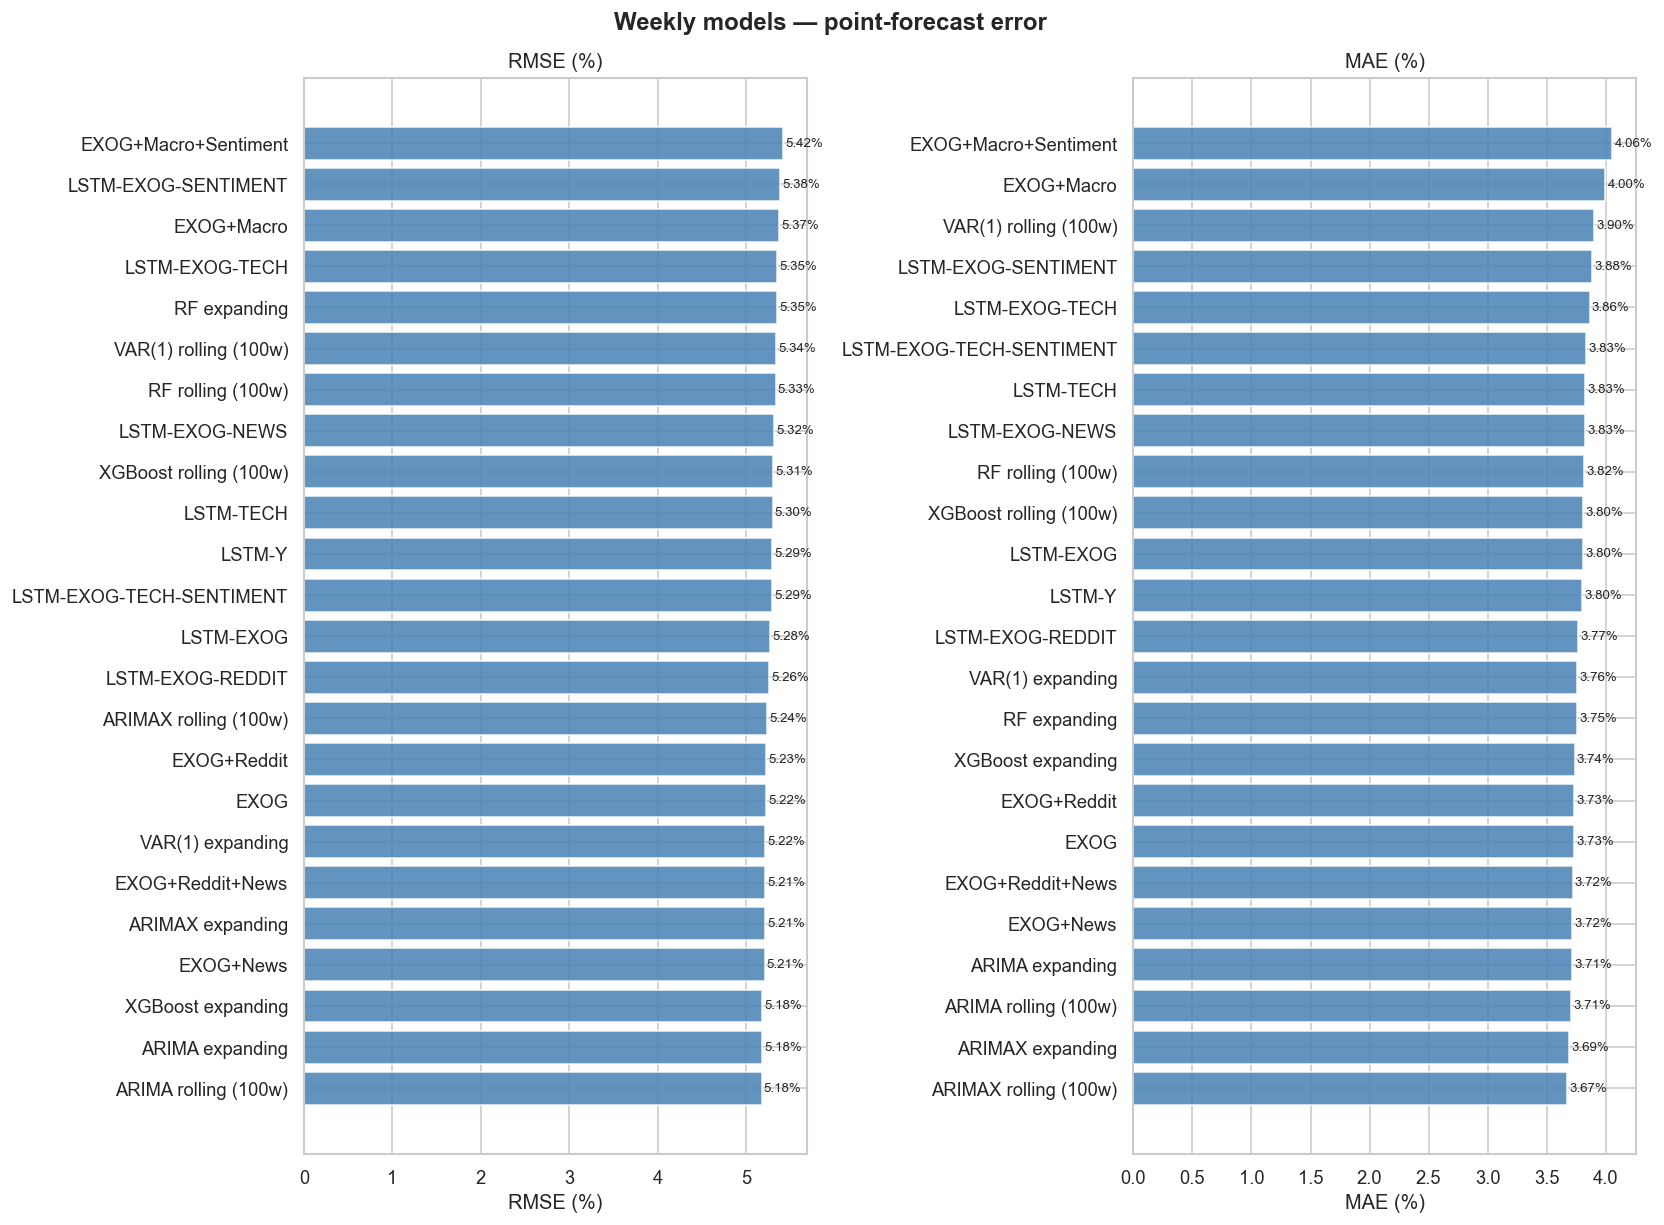

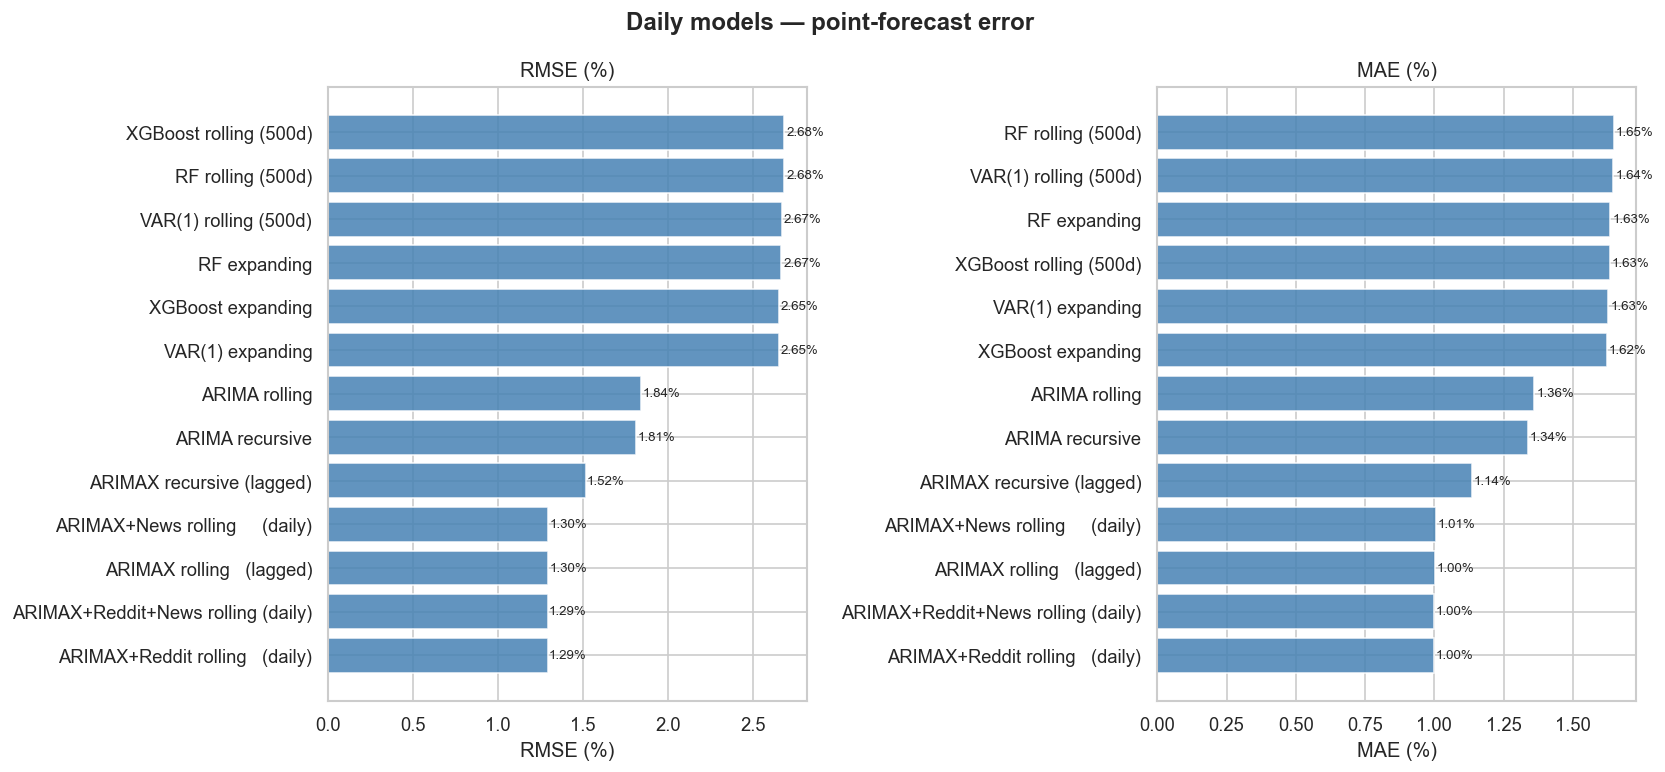

In [187]:
for freq in ['Weekly', 'Daily']:
    sub = models_only[models_only['frequency'] == freq].sort_values('rmse')

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(sub) * 0.35 + 2)))
    fig.suptitle(f'{freq} models — point-forecast error', fontweight='bold')

    for ax, metric, label in zip(axes,
                                  ['rmse', 'mae'],
                                  ['RMSE (%)', 'MAE (%)']):
        df = sub.sort_values(metric, ascending=True)
        ax.barh(df['model'], df[metric], color='steelblue', alpha=0.85)
        ax.set_xlabel(label)
        ax.set_title(label)
        for v, name in zip(df[metric], df['model']):
            ax.text(v * 1.005, name, f'{v:.2f}%', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

## 5. Cross-frequency comparison

For models with both daily and weekly variants: does aggregating to weekly
lose or gain predictive signal?

WDA: weekly vs daily (positive = weekly wins)
               wda_weekly  wda_daily  wda_diff
family                                        
XGBoost             0.582      0.538     0.044
Random Forest       0.495      0.530    -0.035
VAR                 0.498      0.544    -0.046
ARIMA               0.585      0.842    -0.257

RMSE (%): weekly vs daily
               rmse_weekly  rmse_daily  rmse_diff
family                                           
XGBoost               5.18        2.65       2.53
Random Forest         5.35        2.68       2.66
VAR                   5.22        2.65       2.57
ARIMA                 5.18        1.30       3.88


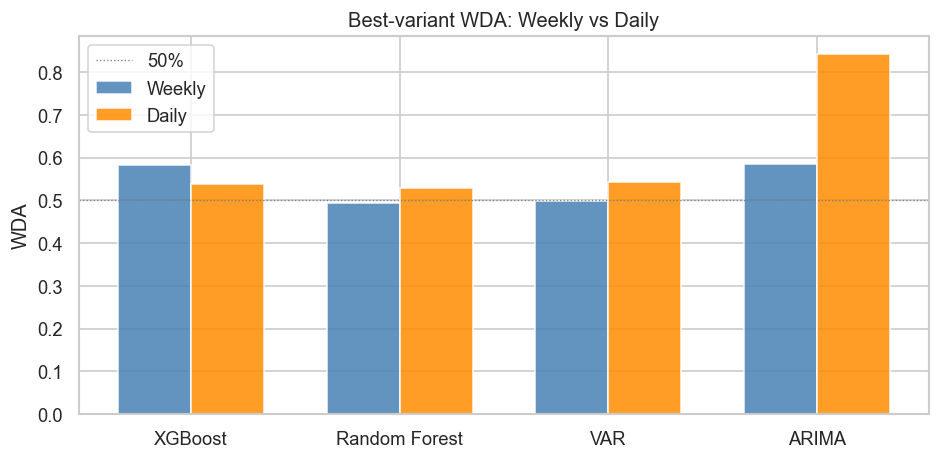

In [188]:
both_freq = set(models_only[models_only['frequency'] == 'Weekly']['family']) & \
            set(models_only[models_only['frequency'] == 'Daily']['family'])

cross = (
    models_only[models_only['family'].isin(both_freq)]
    .sort_values('wda', ascending=False)
    .groupby(['family', 'frequency'])
    .first()
    .reset_index()[['family', 'frequency', 'model', 'wda', 'da', 'rmse']]
)

pivot = cross.pivot(index='family', columns='frequency', values=['wda', 'da', 'rmse'])
pivot.columns = [f'{m}_{f.lower()}' for m, f in pivot.columns]
pivot['wda_diff']  = pivot['wda_weekly']  - pivot['wda_daily']
pivot['rmse_diff'] = pivot['rmse_weekly'] - pivot['rmse_daily']
pivot = pivot.sort_values('wda_diff', ascending=False)
print('WDA: weekly vs daily (positive = weekly wins)')
print(pivot[['wda_weekly', 'wda_daily', 'wda_diff']].round(3).to_string())
print('\nRMSE (%): weekly vs daily')
print(pivot[['rmse_weekly', 'rmse_daily', 'rmse_diff']].round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(pivot))
w = 0.35
ax.bar(x - w/2, pivot['wda_weekly'], w, label='Weekly', color='steelblue', alpha=0.85)
ax.bar(x + w/2, pivot['wda_daily'],  w, label='Daily',  color='darkorange', alpha=0.85)
ax.axhline(0.5, color='grey', lw=0.8, ls=':', label='50%')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_ylabel('WDA')
ax.set_title('Best-variant WDA: Weekly vs Daily')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Sentiment ablation

Does adding retail sentiment improve forecasts?

**ARIMA**: baseline (no exogenous) vs ARIMAX variants (market covariates, Reddit, News, Trends).  
**LSTM**: Y-only vs EXOG (market) vs REDDIT vs NEWS.

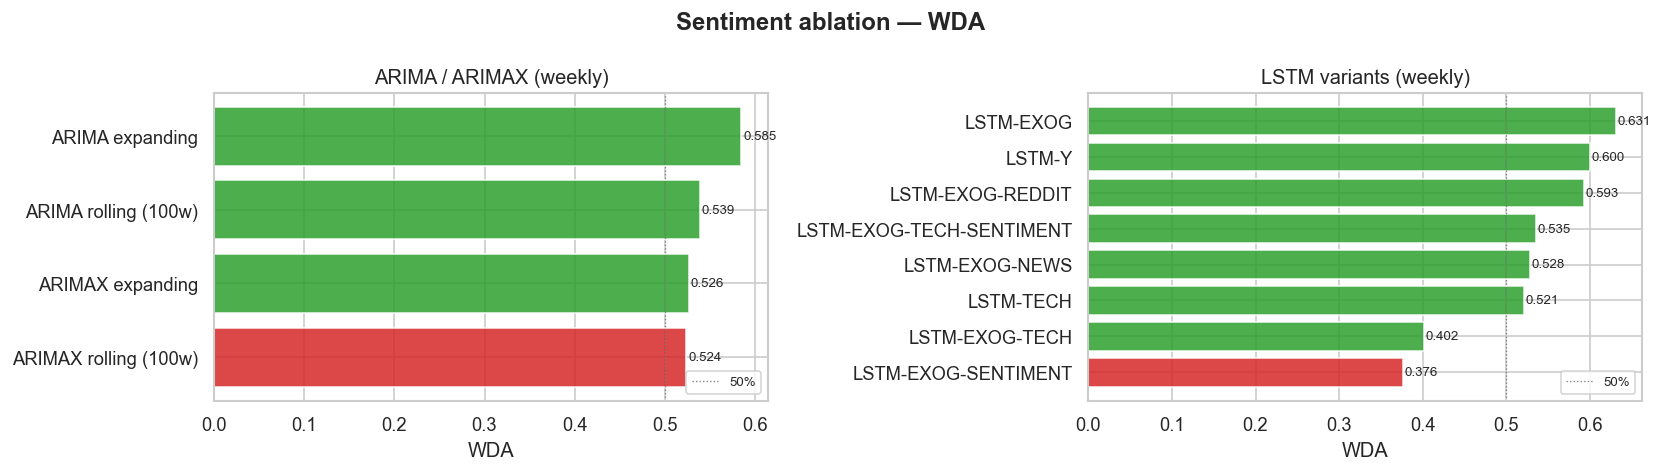

In [189]:
arima_w = all_metrics[
    (all_metrics['family'] == 'ARIMA') &
    (all_metrics['frequency'] == 'Weekly') &
    ~all_metrics['is_naive']
].copy()

lstm_w = all_metrics[
    (all_metrics['family'] == 'LSTM') &
    ~all_metrics['is_naive']
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Sentiment ablation — WDA', fontweight='bold')

for ax, df, title in [
    (axes[0], arima_w, 'ARIMA / ARIMAX (weekly)'),
    (axes[1], lstm_w,  'LSTM variants (weekly)'),
]:
    df_s = df.sort_values('wda', ascending=True)
    baseline_wda = df_s.iloc[0]['wda']
    colors = ['#2ca02c' if v > baseline_wda else '#d62728'
              for v in df_s['wda']]
    ax.barh(df_s['model'], df_s['wda'], color=colors, alpha=0.85)
    ax.axvline(0.5, color='grey', lw=0.8, ls=':', label='50%')
    ax.set_xlabel('WDA')
    ax.set_title(title)
    ax.legend(fontsize=8)
    for v, name in zip(df_s['wda'], df_s['model']):
        ax.text(v + 0.002, name, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 7. MIDAS overview

MIDAS uses monthly macro data (CPI, industrial production, fed funds, real rates)
mixed with the weekly silver return series. Shown separately because it operates
on a shorter test window than the other weekly models.

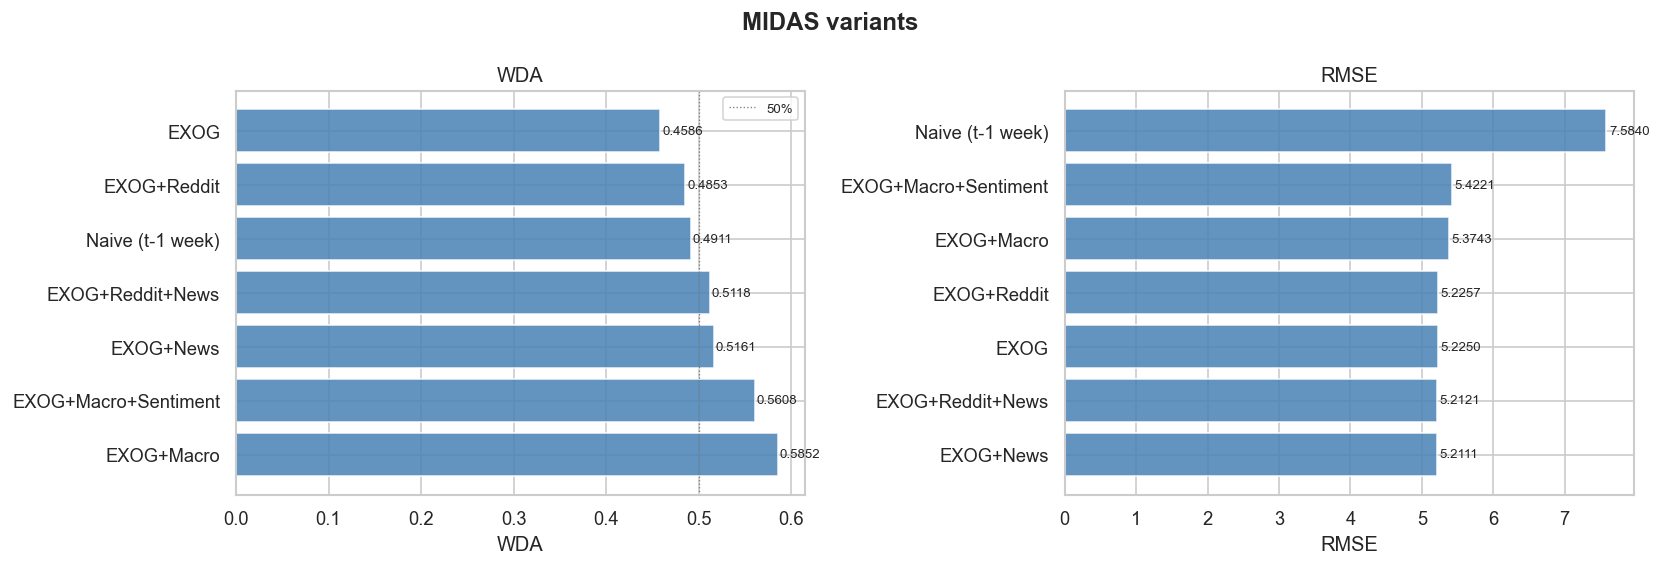

In [190]:
midas = all_metrics[all_metrics['family'] == 'MIDAS'].copy()
midas_s = midas.sort_values('wda', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(midas) * 0.4 + 2)))
fig.suptitle('MIDAS variants', fontweight='bold')

for ax, metric in zip(axes, ['wda', 'rmse']):
    df = midas_s.sort_values(metric, ascending=(metric == 'rmse'))
    ax.barh(df['model'], df[metric], color='steelblue', alpha=0.85)
    if metric == 'wda':
        ax.axvline(0.5, color='grey', lw=0.8, ls=':', label='50%')
        ax.legend(fontsize=8)
    ax.set_xlabel(metric.upper())
    ax.set_title(metric.upper())
    for v, name in zip(df[metric], df['model']):
        offset = 0.002 if metric == 'wda' else df[metric].max() * 0.005
        ax.text(v + offset, name, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Silver Squeeze — LSTM episode analysis

LSTM variants tested specifically on the Jan–Jun 2021 squeeze episode.
Does the model that saw Reddit/news sentiment do better during the peak retail event?

['model', 'period', 'n', 'rmse', 'da', 'wda']


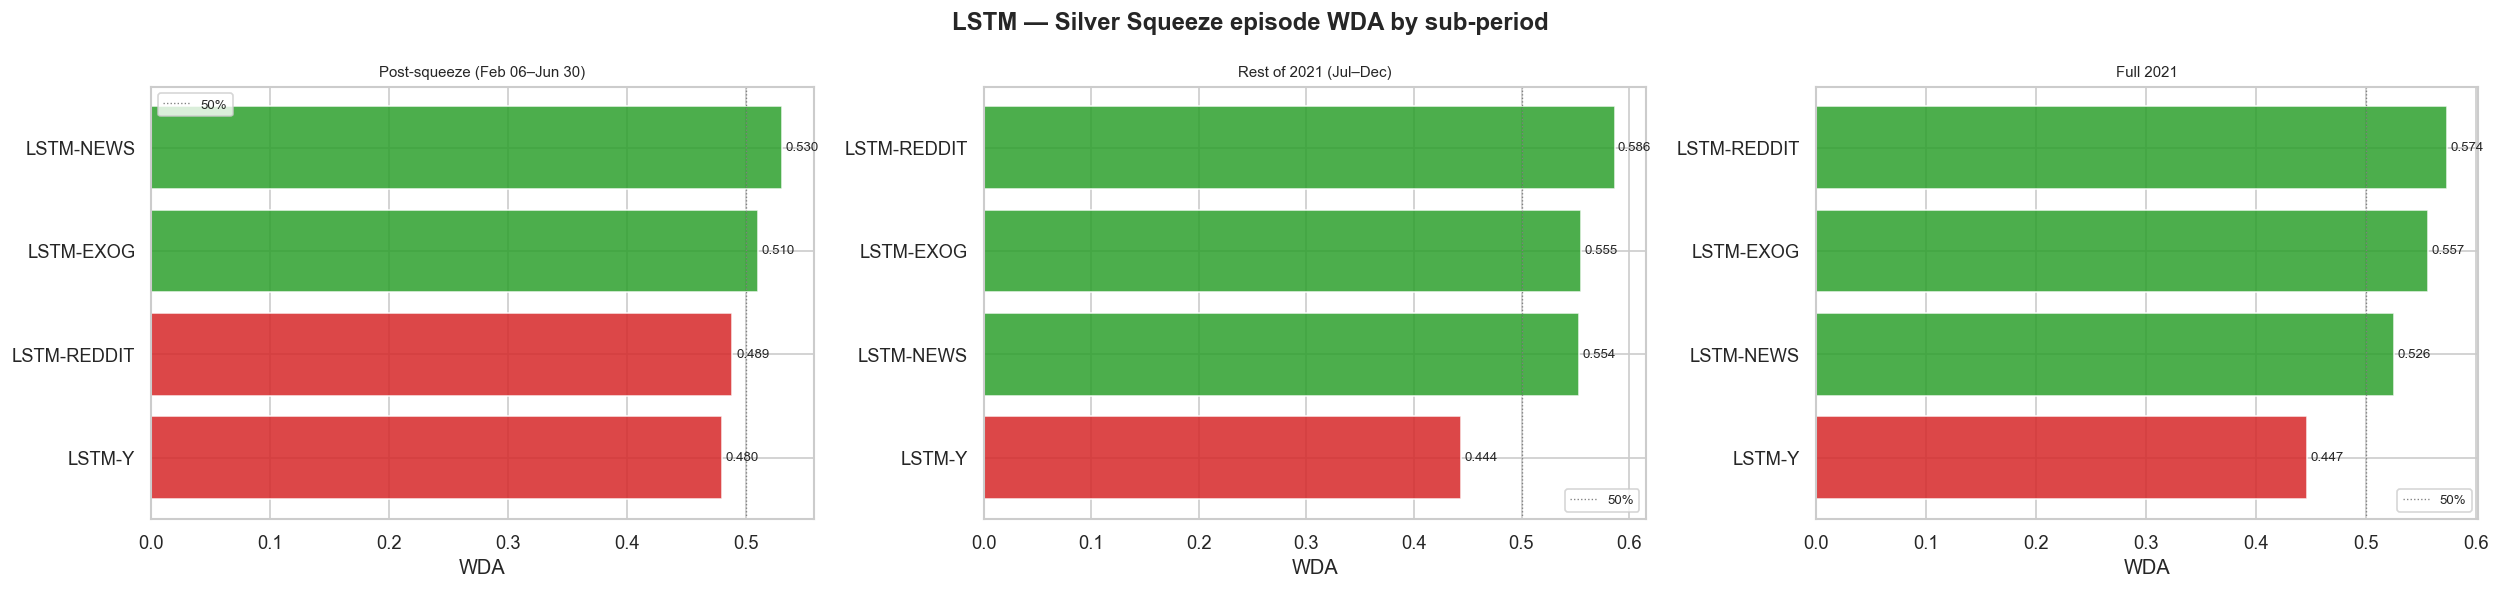

      model                       period   n     rmse       da      wda
     LSTM-Y Post-squeeze (Feb 06–Jun 30) 100 0.016203 0.520000 0.480127
  LSTM-EXOG Post-squeeze (Feb 06–Jun 30) 100 0.016486 0.430000 0.510239
LSTM-REDDIT Post-squeeze (Feb 06–Jun 30) 100 0.019792 0.400000 0.488656
  LSTM-NEWS Post-squeeze (Feb 06–Jun 30) 100 0.016868 0.420000 0.530451
     LSTM-Y       Rest of 2021 (Jul–Dec) 128 0.015820 0.453125 0.443941
  LSTM-EXOG       Rest of 2021 (Jul–Dec) 128 0.015972 0.515625 0.555122
LSTM-REDDIT       Rest of 2021 (Jul–Dec) 128 0.018635 0.539062 0.586474
  LSTM-NEWS       Rest of 2021 (Jul–Dec) 128 0.016164 0.515625 0.553614
     LSTM-Y                    Full 2021 232 0.017610 0.482759 0.447033
  LSTM-EXOG                    Full 2021 232 0.017708 0.482759 0.556909
LSTM-REDDIT                    Full 2021 232 0.020393 0.487069 0.573923
  LSTM-NEWS                    Full 2021 232 0.017973 0.474138 0.526209


In [191]:
squeeze_path = DATA + 'metrics_lstm_squeeze.csv'
if not os.path.exists(squeeze_path):
    print('metrics_lstm_squeeze.csv not found — run weekly/07_lstm_squeeze.ipynb first.')
else:
    squeeze = pd.read_csv(squeeze_path)
    print(squeeze.columns.tolist())

    periods = squeeze['period'].unique()
    n_periods = len(periods)

    fig, axes = plt.subplots(1, n_periods, figsize=(7 * n_periods, 5), sharey=False)
    if n_periods == 1:
        axes = [axes]
    fig.suptitle('LSTM — Silver Squeeze episode WDA by sub-period', fontweight='bold')

    for ax, period in zip(axes, periods):
        sub = squeeze[squeeze['period'] == period].sort_values('wda', ascending=True)
        colors = ['#2ca02c' if v > 0.5 else '#d62728' for v in sub['wda']]
        ax.barh(sub['model'], sub['wda'], color=colors, alpha=0.85)
        ax.axvline(0.5, color='grey', lw=0.8, ls=':', label='50%')
        ax.set_xlabel('WDA')
        ax.set_title(period, fontsize=9)
        ax.legend(fontsize=8)
        for v, name in zip(sub['wda'], sub['model']):
            ax.text(v + 0.003, name, f'{v:.3f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()
    print(squeeze.to_string(index=False))

## 9. Diebold-Mariano tests — ARIMA variants

Tests whether ARIMAX variants are significantly better or worse than the ARIMA baseline.
Uses saved prediction files (`preds_*.csv`); squared-error loss, Newey-West variance (lag=1).

In [192]:
def diebold_mariano(actual, pred1, pred2, name1='Model 1', name2='Model 2'):
    e1 = actual - pred1
    e2 = actual - pred2
    d  = e1**2 - e2**2
    T  = len(d)
    d_bar = d.mean()
    # Newey-West variance with lag 1
    gamma0 = np.mean((d - d_bar)**2)
    gamma1 = np.mean((d[1:] - d_bar) * (d[:-1] - d_bar))
    nw_var = (gamma0 + 2 * gamma1) / T
    dm_stat = d_bar / np.sqrt(max(nw_var, 1e-12))
    p_val   = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    winner  = name1 if dm_stat < 0 else name2
    sig     = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    print(f'  {name1:<30} vs {name2:<30}  DM={dm_stat:+.3f}  p={p_val:.3f}{sig}  better={winner}')
    return {'name1': name1, 'name2': name2, 'dm': dm_stat, 'p': p_val, 'winner': winner}

# Load ARIMA baseline predictions
preds_files = {
    'ARIMA rolling':        'preds_arima_rol.csv',
    'ARIMAX rolling':       'preds_arimax_rol.csv',
    'ARIMAX + Reddit':      'preds_arimax_reddit_rol.csv',
    'ARIMAX + News':        'preds_arimax_news_rol.csv',
    'ARIMAX + Trends':      'preds_arimax_trends_rol.csv',
    'ARIMAX + Reddit+News': 'preds_arimax_both_rol.csv',
    'ARIMAX + R+N+Trends':  'preds_arimax_reddit_trends_rol.csv',
}

preds = {}
for name, fname in preds_files.items():
    path = DATA + fname
    if os.path.exists(path):
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        preds[name] = df
    else:
        print(f'Missing: {fname}')

print(f'Loaded {len(preds)} prediction series\n')

if 'ARIMA rolling' in preds:
    baseline = preds['ARIMA rolling']
    actual   = baseline['actual'].values
    pred_b   = baseline['predicted'].values

    print('H₀: equal predictive accuracy vs ARIMA rolling baseline')
    print('  Negative DM → baseline is better; Positive DM → challenger is better\n')
    results = []
    for name, df in preds.items():
        if name == 'ARIMA rolling':
            continue
        common = baseline.index.intersection(df.index)
        r = diebold_mariano(
            baseline.loc[common, 'actual'].values,
            pred_b[:len(common)],
            df.loc[common, 'predicted'].values,
            name1='ARIMA rolling',
            name2=name,
        )
        results.append(r)
    print('\n* p<0.05  ** p<0.01  *** p<0.001')

Loaded 7 prediction series

H₀: equal predictive accuracy vs ARIMA rolling baseline
  Negative DM → baseline is better; Positive DM → challenger is better

  ARIMA rolling                  vs ARIMAX rolling                  DM=-1.048  p=0.294  better=ARIMA rolling
  ARIMA rolling                  vs ARIMAX + Reddit                 DM=-1.714  p=0.087  better=ARIMA rolling
  ARIMA rolling                  vs ARIMAX + News                   DM=-0.927  p=0.354  better=ARIMA rolling
  ARIMA rolling                  vs ARIMAX + Trends                 DM=-1.146  p=0.252  better=ARIMA rolling
  ARIMA rolling                  vs ARIMAX + Reddit+News            DM=-1.383  p=0.167  better=ARIMA rolling
  ARIMA rolling                  vs ARIMAX + R+N+Trends             DM=-1.027  p=0.304  better=ARIMA rolling

* p<0.05  ** p<0.01  *** p<0.001


## 10. Summary table — thesis-ready

One row per model family × frequency showing the best-variant metrics.

In [193]:
summary = (
    best[['frequency', 'family', 'model', 'rmse', 'mae', 'da', 'wda']]
    .rename(columns={
        'frequency': 'Frequency',
        'family':    'Model',
        'model':     'Best variant',
        'rmse':      'RMSE (%)',
        'mae':       'MAE (%)',
        'da':        'DA',
        'wda':       'WDA',
    })
    .sort_values(['Frequency', 'WDA'], ascending=[True, False])
)

# Append always-up baseline rows as reference
au_rows = all_metrics[all_metrics['model'] == 'Always-up (drift)'][
    ['frequency', 'da', 'wda']
].rename(columns={'frequency': 'Frequency', 'da': 'DA', 'wda': 'WDA'})
au_rows['Model']       = '── Baseline ──'
au_rows['Best variant'] = 'Always-up (drift)'
au_rows['RMSE (%)']    = float('nan')
au_rows['MAE (%)']     = float('nan')
summary = pd.concat([summary, au_rows], ignore_index=True)

summary[['RMSE (%)', 'MAE (%)']] = summary[['RMSE (%)', 'MAE (%)']].round(2)
summary[['DA', 'WDA']]           = summary[['DA', 'WDA']].round(3)

print(summary.to_string(index=False))

# LaTeX
# latex = summary.to_latex(index=False, float_format='%.2f',
#                           caption='Model comparison — best variant per family',
#                           label='tab:model_comparison', na_rep='—')
# print('\n── LaTeX ──')
# print(latex)

Frequency          Model              Best variant  RMSE (%)  MAE (%)    DA   WDA
    Daily          ARIMA ARIMAX rolling   (lagged)      1.30     1.00 0.696 0.842
    Daily            VAR          VAR(1) expanding      2.65     1.63 0.480 0.544
    Daily        XGBoost         XGBoost expanding      2.65     1.62 0.502 0.538
    Daily  Random Forest         RF rolling (500d)      2.68     1.65 0.500 0.530
   Weekly           LSTM                 LSTM-EXOG      5.28     3.80 0.576 0.631
   Weekly          MIDAS                EXOG+Macro      5.37     4.00 0.549 0.585
   Weekly          ARIMA           ARIMA expanding      5.18     3.71 0.554 0.585
   Weekly        XGBoost         XGBoost expanding      5.18     3.74 0.531 0.582
   Weekly            VAR          VAR(1) expanding      5.22     3.76 0.503 0.498
   Weekly  Random Forest              RF expanding      5.35     3.75 0.520 0.495
   Weekly ── Baseline ──         Always-up (drift)       NaN      NaN 0.554 0.585
    Daily ── Bas

## 11. Period breakdown — WDA by calendar year

Splits each model's best-variant predictions into sub-periods to check whether
good overall WDA is consistent across market regimes or driven by one lucky stretch.
Covers all 10 model variants (6 weekly including LSTM and MIDAS, 4 daily).

Periods: 2023 (choppy), 2024 (bull start), 2025 (bull run), 2026 YTD.

Missing: period_arimax_weekly.csv — run the model notebook first
Missing: period_lstm_daily.csv — run the model notebook first
Missing: period_arima_daily.csv — run the model notebook first
Missing: period_var_daily.csv — run the model notebook first
Missing: period_rf_daily.csv — run the model notebook first
Missing: period_xgboost_daily.csv — run the model notebook first


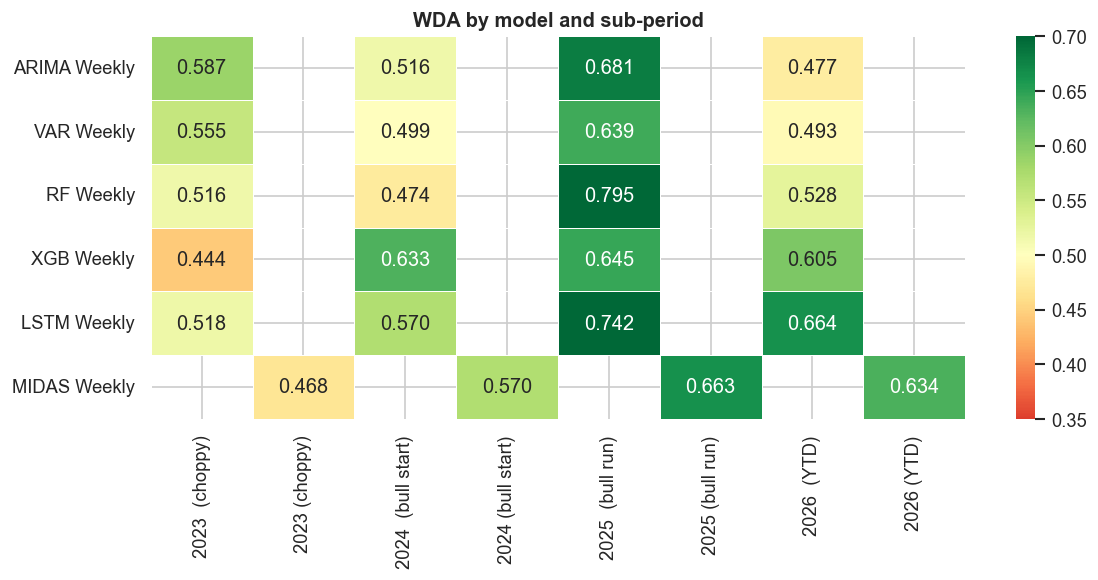

Consistency across sub-periods (lower Std = more stable):


,Full WDA,Mean (years),Std (years),Min (year),Max (year)
Model,,,,,
LSTM Weekly,0.631,0.623,0.099,0.518,0.742
RF Weekly,0.589,0.578,0.147,0.474,0.795
MIDAS Weekly,0.585,0.584,0.086,0.468,0.663
XGB Weekly,0.582,0.582,0.093,0.444,0.645
ARIMA Weekly,0.572,0.565,0.089,0.477,0.681
VAR Weekly,0.552,0.547,0.068,0.493,0.639


In [194]:
period_map = {
    'ARIMA Weekly':  'period_arima_weekly.csv',
    'ARIMAX Weekly': 'period_arimax_weekly.csv',
    'VAR Weekly':    'period_var_weekly.csv',
    'RF Weekly':     'period_rf_weekly.csv',
    'XGB Weekly':    'period_xgboost_weekly.csv',
    'LSTM Weekly':   'period_lstm_weekly.csv',
    'LSTM Daily':    'period_lstm_daily.csv',
    'MIDAS Weekly':  'period_midas_weekly.csv',
    'ARIMA Daily':   'period_arima_daily.csv',
    'VAR Daily':     'period_var_daily.csv',
    'RF Daily':      'period_rf_daily.csv',
    'XGB Daily':     'period_xgboost_daily.csv',
}

period_frames = {}
for label, fname in period_map.items():
    path = DATA + fname
    if os.path.exists(path):
        period_frames[label] = pd.read_csv(path, index_col=0)
    else:
        print(f'Missing: {fname} — run the model notebook first')

if not period_frames:
    print('No period files found. Re-run model notebooks to generate them.')
else:
    # Build WDA matrix: rows=model, columns=period
    wda_matrix = pd.DataFrame({lbl: df['WDA'] for lbl, df in period_frames.items()}).T
    wda_matrix.index.name = 'Model'

    full_col  = '── Full test ──'
    year_cols = [c for c in wda_matrix.columns if c != full_col]

    # ── heatmap (year sub-periods only) ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        wda_matrix[year_cols],
        annot=True, fmt='.3f', cmap='RdYlGn',
        vmin=0.35, vmax=0.70, center=0.50,
        linewidths=0.5, ax=ax,
    )
    ax.set_title('WDA by model and sub-period', fontweight='bold')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

    # ── consistency table ─────────────────────────────────────────────────────
    consistency = pd.DataFrame({
        'Full WDA':  wda_matrix[full_col] if full_col in wda_matrix.columns else np.nan,
        'Mean (years)': wda_matrix[year_cols].mean(axis=1),
        'Std (years)':  wda_matrix[year_cols].std(axis=1),
        'Min (year)':   wda_matrix[year_cols].min(axis=1),
        'Max (year)':   wda_matrix[year_cols].max(axis=1),
    }).sort_values('Full WDA', ascending=False)

    print('Consistency across sub-periods (lower Std = more stable):')
    display(consistency.style
            .format('{:.3f}')
            .background_gradient(cmap='RdYlGn', subset=['Full WDA', 'Mean (years)'], vmin=0.38, vmax=0.68)
            .background_gradient(cmap='RdYlGn_r', subset=['Std (years)'], vmin=0.0, vmax=0.15))